# Combates Eternos en el Netherrealm

Se simula concurrentemente una gran cantidad de torneos independientes de Mortal Kombat II. Cada torneo selecciona 8 luchadores al azar de entre 12 disponibles y los enfrenta en un cuadro eliminatorio (cuartos, semifinal y final) hasta obtener un campeon.

El programa (`main.py`, junto a `fighter.py`, `fight.py` y `tournament.py`) reparte la cantidad total de torneos entre N hilos, sin que estos se comuniquen ni sincronicen entre si (unico punto de coordinacion: `join()` desde el hilo principal). Cada hilo acumula sus propios resultados (turnos simulados, victorias por combate y campeonatos por luchador) y al final se mide el tiempo total de ejecucion.

Esta notebook ejecuta el programa ya implementado (via `subprocess`, tal como esta pensado para usarse desde la linea de comandos) para mostrar sus resultados y para medir como varia el tiempo de ejecucion segun la cantidad de hilos utilizados.

## Resultados de una simulacion

Ejecutamos el programa una vez con 10.000 torneos y 4 hilos para ver el formato de salida: cada hilo imprime, de forma independiente, las victorias totales y los campeonatos por luchador que le tocaron simular, ademas del tiempo de ejecucion total.

In [1]:
import re
import subprocess
import sys

resultado = subprocess.run(
    [sys.executable, "main.py", "10000", "-t", "4"],
    capture_output=True,
    text=True,
    check=True,
)
print(resultado.stdout)

Fighter: Liu Kang - Total Wins: 1308 - Championships: 139
Fighter: Kung Lao - Total Wins: 850 - Championships: 55
Fighter: Johnny Cage - Total Wins: 1250 - Championships: 94
Fighter: Reptile - Total Wins: 1090 - Championships: 76
Fighter: Sub-Zero - Total Wins: 2969 - Championships: 724
Fighter: Shang Tsung - Total Wins: 474 - Championships: 18
Fighter: Kitana - Total Wins: 711 - Championships: 29
Fighter: Jax - Total Wins: 2380 - Championships: 419
Fighter: Mileena - Total Wins: 725 - Championships: 33
Fighter: Baraka - Total Wins: 2186 - Championships: 392
Fighter: Scorpion - Total Wins: 2003 - Championships: 348
Fighter: Raiden - Total Wins: 1554 - Championships: 173
Fighter: Liu Kang - Total Wins: 1271 - Championships: 128
Fighter: Kung Lao - Total Wins: 827 - Championships: 51
Fighter: Johnny Cage - Total Wins: 1231 - Championships: 100
Fighter: Reptile - Total Wins: 1018 - Championships: 62
Fighter: Sub-Zero - Total Wins: 2992 - Championships: 717
Fighter: Shang Tsung - Total Win

## Medicion del tiempo segun la cantidad de hilos

Se mantiene fija la cantidad de torneos simulados (10.000) y se varia la cantidad de hilos. Para cada configuracion se repite la ejecucion 3 veces y se calcula el tiempo promedio, dado que la ejecucion concurrente tiene variabilidad propia.

In [2]:
import statistics

_TOURNAMENTS = 10000
_THREAD_COUNTS = [1, 2, 4, 8, 12]
_REPETICIONES = 3
_PATRON_TIEMPO = re.compile(r"Execution time: ([\d.]+) seconds")


def medir_tiempo(threads: int) -> float:
    """Ejecuta main.py con la cantidad de hilos indicada y devuelve el tiempo en segundos."""
    resultado = subprocess.run(
        [sys.executable, "main.py", str(_TOURNAMENTS), "-t", str(threads)],
        capture_output=True,
        text=True,
        check=True,
    )
    return float(_PATRON_TIEMPO.search(resultado.stdout).group(1))


tiempos_promedio = []
for threads in _THREAD_COUNTS:
    tiempos = [medir_tiempo(threads) for _ in range(_REPETICIONES)]
    promedio = statistics.mean(tiempos)
    tiempos_promedio.append(promedio)
    print(f"Hilos: {threads:>2} - Tiempos: {[f'{t:.3f}' for t in tiempos]} - Promedio: {promedio:.3f} s")

Hilos:  1 - Tiempos: ['4.093', '4.480', '4.034'] - Promedio: 4.202 s


Hilos:  2 - Tiempos: ['4.278', '4.561', '4.230'] - Promedio: 4.357 s


Hilos:  4 - Tiempos: ['4.248', '4.582', '4.421'] - Promedio: 4.417 s


Hilos:  8 - Tiempos: ['4.407', '4.276', '4.440'] - Promedio: 4.374 s


Hilos: 12 - Tiempos: ['4.360', '4.236', '4.393'] - Promedio: 4.330 s


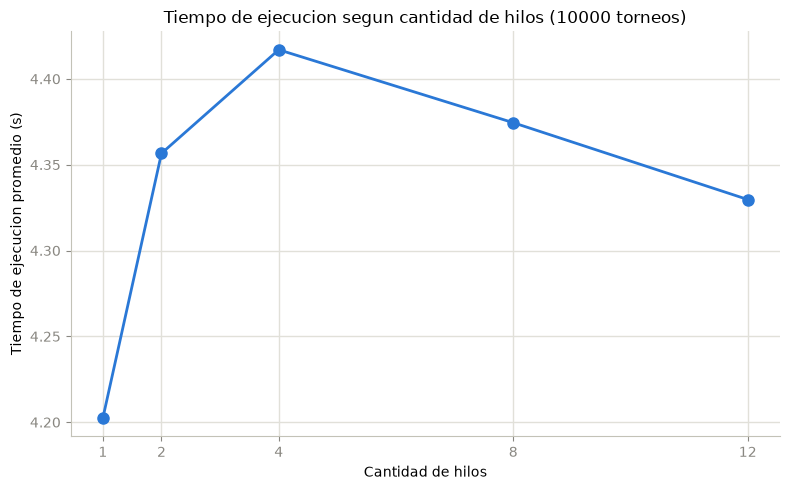

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    _THREAD_COUNTS,
    tiempos_promedio,
    marker="o",
    markersize=8,
    linewidth=2,
    color="#2a78d6",
)
ax.set_xlabel("Cantidad de hilos")
ax.set_ylabel("Tiempo de ejecucion promedio (s)")
ax.set_title(f"Tiempo de ejecucion segun cantidad de hilos ({_TOURNAMENTS} torneos)")
ax.set_xticks(_THREAD_COUNTS)
ax.grid(True, color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")

ax.tick_params(colors="#898781")
plt.tight_layout()
plt.show()

### Conclusion

El tiempo de ejecucion se mantiene practicamente constante (e incluso aumenta levemente) a medida que se agregan hilos, en lugar de reducirse. Esto se debe a que la simulacion es una carga puramente CPU-bound implementada en Python puro, y el GIL (Global Interpreter Lock) impide que multiples hilos ejecuten bytecode Python en paralelo sobre distintos nucleos: solo un hilo corre efectivamente a la vez, y el resto del tiempo se agrega overhead de creacion/cambio de contexto entre hilos. Por lo tanto, con este modelo de concurrencia (hilos de Python para trabajo CPU-bound) no se obtiene una mejora real de rendimiento; para aprovechar los multiples nucleos disponibles seria necesario usar procesos (por ejemplo `multiprocessing`) en lugar de hilos.